# Tratamento da Unidade MÃ³vel Caju

Este notebook organiza o tratamento horÃ¡rio da Unidade MÃ³vel `Caju` em quatro blocos simples:

1. padronizar o calendÃ¡rio horÃ¡rio;
2. interpolar apenas lacunas internas curtas;
3. validar o impacto do tratamento.

## Bibliotecas e configuraÃ§Ãµes

ComeÃ§amos carregando as bibliotecas que serÃ£o usadas ao longo do notebook e localizando automaticamente a raiz do projeto. Isso evita depender do diretÃ³rio manual de execuÃ§Ã£o do notebook.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

## Carregamento da base da Unidade MÃ³vel

Nesta etapa, carregamos a base consolidada de qualidade do ar, normalizamos o nome da Unidade MÃ³vel para evitar problemas de codificaÃ§Ã£o e isolamos apenas os registros da Unidade MÃ³vel `Caju`.

In [2]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_um_caju = df_air_quality[df_air_quality["Nome"] == "UNIDADE MOVEL CAJU"].copy()

df_um_caju["data"] = pd.to_datetime(df_um_caju["data"])
df_um_caju = df_um_caju.sort_values("data").reset_index(drop=True)
df_um_caju = df_um_caju.drop_duplicates(subset="data", keep="first")
df_um_caju = df_um_caju.set_index("data").sort_index().copy()

print("Dimensoes da base da Unidade MÃ³vel Caju:", df_um_caju.shape)
display(df_um_caju.head())

Dimensoes da base da Unidade MÃ³vel Caju: (12656, 14)


,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
data,,,,,,,,,,,,,,
2013-02-21 11:30:00,UNIDADE MOVEL CAJU,0.0,34.05,46.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-22.875845,-43.222494
2013-02-21 12:30:00,UNIDADE MOVEL CAJU,0.0,35.23,39.25,22.11,NaN,0.0,NaN,NaN,0.0,NaN,NaN,-22.875845,-43.222494
2013-02-21 13:30:00,UNIDADE MOVEL CAJU,0.0,36.37,36.43,27.97,NaN,0.0,NaN,NaN,0.0,NaN,NaN,-22.875845,-43.222494
2013-02-21 14:30:00,UNIDADE MOVEL CAJU,0.0,37.92,31.60,31.52,NaN,0.0,NaN,NaN,0.0,NaN,NaN,-22.875845,-43.222494
2013-02-21 15:30:00,UNIDADE MOVEL CAJU,0.0,37.88,35.57,33.75,NaN,0.0,NaN,NaN,0.0,NaN,11.0,-22.875845,-43.222494


## Resumo das faltas antes do tratamento

Com o calendÃ¡rio padronizado, agora medimos o tamanho do problema de missing antes de qualquer imputaÃ§Ã£o. Essa tabela serve como linha de base para comparar o efeito do tratamento depois.

In [3]:
variaveis_ambientais = [
'no',
'no2',
'so2',
'pm2_5',
'nox',
'ur',
'temp',
'o3',
'co',
'pm10',
'chuva'
]
    

def resumir_faltantes(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    total_linhas = len(df)
    resumo = pd.DataFrame(index=variaveis)
    resumo["faltantes"] = [int(df[col].isna().sum()) for col in variaveis]
    resumo["missing_pct"] = [round(100 * df[col].isna().mean(), 2) for col in variaveis]
    resumo["validos"] = total_linhas - resumo["faltantes"]
    return resumo.sort_values("faltantes", ascending=False)


resumo_missing_antes = resumir_faltantes(df_um_caju, variaveis_ambientais)
display(resumo_missing_antes)

,faltantes,missing_pct,validos
no,12656,100.00,0
no2,12656,100.00,0
nox,12656,100.00,0
pm10,12656,100.00,0
co,1244,9.83,11412
so2,1104,8.72,11552
ur,351,2.77,12305
o3,333,2.63,12323
pm2_5,333,2.63,12323
chuva,165,1.30,12491


## Regra de imputaÃ§Ã£o adotada

O tratamento escolhido aqui Ã© propositalmente conservador:

- interpolar apenas lacunas internas de atÃ© `4` horas consecutivas;
- nÃ£o extrapolar bordas da sÃ©rie;
- nÃ£o interpolar `chuva`, porque a interpolaÃ§Ã£o linear pode criar eventos artificiais.

Com isso, preservamos a rastreabilidade do tratamento e evitamos preencher ausÃªncias longas ou estruturalmente mais problemÃ¡ticas.

In [4]:
MAX_GAP_HORAS = 4

variaveis_interpolar = [
    "temp",
    "ur",
    "so2",
    "no2",
    "co",
    "no",
    "nox",
    "o3",
    "pm10",
    "pm2_5",
]


def mascara_lacunas_internas_curtas(serie: pd.Series, max_gap: int = 4) -> pd.Series:
    faltante = serie.isna()
    if not faltante.any():
        return pd.Series(False, index=serie.index)

    grupos = faltante.ne(faltante.shift(fill_value=False)).cumsum()
    tamanho_grupo = faltante.groupby(grupos).transform("sum")
    tem_valor_antes = serie.ffill().notna()
    tem_valor_depois = serie.bfill().notna()

    return faltante & tem_valor_antes & tem_valor_depois & (tamanho_grupo <= max_gap)

df_um_caju_tratado = df_um_caju.copy()

registros_imputacao = []

for variavel in variaveis_ambientais:
    serie_original = df_um_caju[variavel]

    if variavel in variaveis_interpolar:
        mascara_gap_curto = mascara_lacunas_internas_curtas(serie_original, max_gap=MAX_GAP_HORAS)
        serie_interpolada = serie_original.interpolate(method="time", limit_area="inside")
        df_um_caju_tratado.loc[mascara_gap_curto, variavel] = serie_interpolada.loc[mascara_gap_curto]
        valores_imputados = int((mascara_gap_curto & serie_interpolada.notna()).sum())
        metodo = "interpolate_time"

    else:
        mascara_gap_curto = pd.Series(False, index=serie_original.index)
        valores_imputados = 0
        metodo = "sem_interpolacao"

    registros_imputacao.append(
        {
            "variavel": variavel,
            "metodo": metodo,
            "faltantes_antes": int(serie_original.isna().sum()),
            "faltantes_depois": int(df_um_caju_tratado[variavel].isna().sum()),
            "valores_imputados": valores_imputados,
        }
    )

resumo_imputacao = pd.DataFrame(registros_imputacao).sort_values(
    ["valores_imputados", "faltantes_antes"],
    ascending=[False, False],
)

display(resumo_imputacao)

,variavel,metodo,faltantes_antes,faltantes_depois,valores_imputados
2,so2,interpolate_time,1104,499,605
8,co,interpolate_time,1244,866,378
7,o3,interpolate_time,333,154,179
3,pm2_5,interpolate_time,333,209,124
6,temp,interpolate_time,155,94,61
5,ur,interpolate_time,351,291,60
0,no,interpolate_time,12656,12656,0
1,no2,interpolate_time,12656,12656,0
4,nox,interpolate_time,12656,12656,0
9,pm10,interpolate_time,12656,12656,0


## ValidaÃ§Ã£o do impacto do tratamento

Depois da imputaÃ§Ã£o, validamos o impacto em duas frentes:

- reduÃ§Ã£o do missing por variÃ¡vel;
- estabilidade de estatÃ­sticas bÃ¡sicas antes e depois do tratamento.

Como a regra de imputaÃ§Ã£o Ã© curta e conservadora, a expectativa Ã© reduzir uma parte das lacunas sem alterar de forma relevante o comportamento geral das sÃ©ries.

Total de valores imputados: 1407


,faltantes_antes,missing_pct_antes,faltantes_depois,missing_pct_depois,reducao_absoluta,reducao_relativa_pct
so2,1104,8.72,499,3.94,605,54.80
co,1244,9.83,866,6.84,378,30.39
o3,333,2.63,154,1.22,179,53.75
pm2_5,333,2.63,209,1.65,124,37.24
temp,155,1.22,94,0.74,61,39.35
ur,351,2.77,291,2.30,60,17.09
no,12656,100.00,12656,100.00,0,0.00
nox,12656,100.00,12656,100.00,0,0.00
no2,12656,100.00,12656,100.00,0,0.00
pm10,12656,100.00,12656,100.00,0,0.00


,media_antes,mediana_antes,desvio_padrao_antes,media_depois,mediana_depois,desvio_padrao_depois,delta_media,delta_desvio_padrao
so2,11.034278,5.52,16.235916,10.972768,5.54,16.079311,-0.061510,-0.156604
pm2_5,20.551002,16.00,17.474160,20.618510,16.00,18.030508,0.067508,0.556348
ur,69.899531,71.28,15.009080,69.893671,71.27,15.001247,-0.005860,-0.007833
temp,25.961796,25.63,4.151458,25.957873,25.63,4.152707,-0.003923,0.001249
o3,18.121090,9.58,23.264252,18.192309,9.66,23.311468,0.071220,0.047215
co,0.255382,0.18,0.355652,0.255988,0.18,0.352410,0.000606,-0.003242
chuva,0.088544,0.00,0.967613,0.088544,0.00,0.967613,0.000000,0.000000


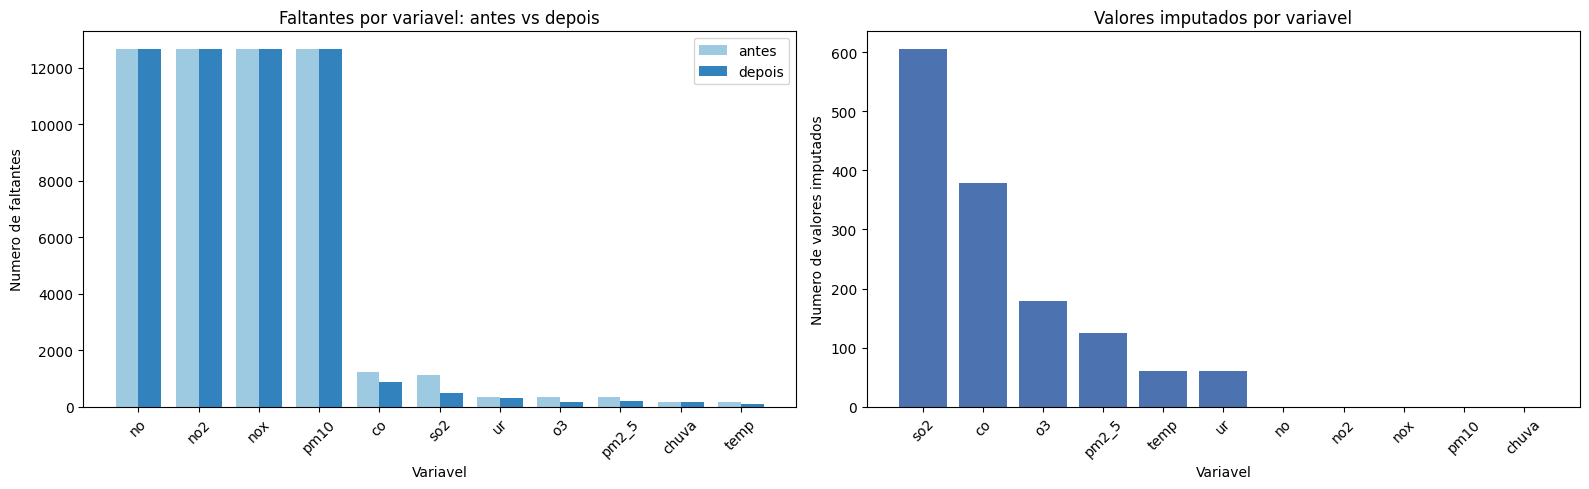

In [5]:
def estatisticas_basicas(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    resumo = pd.DataFrame(index=variaveis)
    resumo["media"] = [df[col].mean() for col in variaveis]
    resumo["mediana"] = [df[col].median() for col in variaveis]
    resumo["desvio_padrao"] = [df[col].std() for col in variaveis]
    return resumo


resumo_missing_depois = resumir_faltantes(df_um_caju_tratado, variaveis_ambientais)

comparativo_missing = resumo_missing_antes[["faltantes", "missing_pct"]].rename(
    columns={
        "faltantes": "faltantes_antes",
        "missing_pct": "missing_pct_antes",
    }
).join(
    resumo_missing_depois[["faltantes", "missing_pct"]].rename(
        columns={
            "faltantes": "faltantes_depois",
            "missing_pct": "missing_pct_depois",
        }
    )
)
comparativo_missing["reducao_absoluta"] = (
    comparativo_missing["faltantes_antes"] - comparativo_missing["faltantes_depois"]
)
comparativo_missing["reducao_relativa_pct"] = (
    100 * comparativo_missing["reducao_absoluta"] / comparativo_missing["faltantes_antes"].replace(0, pd.NA)
).round(2)

variaveis_com_dados = [
    variavel
    for variavel in variaveis_ambientais
    if df_um_caju[variavel].notna().any() or df_um_caju_tratado[variavel].notna().any()
]

estatisticas_antes = estatisticas_basicas(df_um_caju, variaveis_com_dados).add_suffix("_antes")
estatisticas_depois = estatisticas_basicas(df_um_caju_tratado, variaveis_com_dados).add_suffix("_depois")
comparativo_estatistico = estatisticas_antes.join(estatisticas_depois)
comparativo_estatistico["delta_media"] = (
    comparativo_estatistico["media_depois"] - comparativo_estatistico["media_antes"]
)
comparativo_estatistico["delta_desvio_padrao"] = (
    comparativo_estatistico["desvio_padrao_depois"] - comparativo_estatistico["desvio_padrao_antes"]
)

print(f"Total de valores imputados: {int(resumo_imputacao['valores_imputados'].sum())}")
display(comparativo_missing.sort_values("reducao_absoluta", ascending=False))
display(comparativo_estatistico)

comparativo_missing_plot = comparativo_missing.reset_index(names="variavel")
resumo_imputacao_plot = resumo_imputacao.sort_values("valores_imputados", ascending=False)

x_missing = range(len(comparativo_missing_plot))
largura = 0.38
x_imputacao = range(len(resumo_imputacao_plot))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(
    [x - largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_antes"],
    width=largura,
    label="antes",
    color="#9ecae1",
)
axes[0].bar(
    [x + largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_depois"],
    width=largura,
    label="depois",
    color="#3182bd",
)
axes[0].set_title("Faltantes por variavel: antes vs depois")
axes[0].set_xlabel("Variavel")
axes[0].set_ylabel("Numero de faltantes")
axes[0].set_xticks(list(x_missing))
axes[0].set_xticklabels(comparativo_missing_plot["variavel"], rotation=45)
axes[0].legend()

axes[1].bar(
    list(x_imputacao),
    resumo_imputacao_plot["valores_imputados"],
    color="#4c72b0",
)
axes[1].set_title("Valores imputados por variavel")
axes[1].set_xlabel("Variavel")
axes[1].set_ylabel("Numero de valores imputados")
axes[1].set_xticks(list(x_imputacao))
axes[1].set_xticklabels(resumo_imputacao_plot["variavel"], rotation=45)

plt.tight_layout()
plt.show()

## Salvamento da base tratada

Por fim, salvamos a sÃ©rie horÃ¡ria tratada da Unidade MÃ³vel `Caju`. A base final inclui:

- calendÃ¡rio horÃ¡rio padronizado;
- variÃ¡veis tratadas.

Essa saÃ­da jÃ¡ fica pronta para ser reutilizada na etapa de unificaÃ§Ã£o das estaÃ§Ãµes.

In [6]:
project_root = Path().resolve().parents[4]
output_dir = project_root / "Data" / "IntermediaryData" / "MonitorAr" / "TreatedStations"
output_dir.mkdir(parents=True, exist_ok=True)

df_um_caju_tratado_saida = df_um_caju_tratado.reset_index()

output_csv_path = output_dir / "um_caju_tratado.csv"
df_um_caju_tratado_saida.to_csv(output_csv_path, index=False, encoding="utf-8")

print(f"Arquivo salvo em: {output_csv_path}")

Arquivo salvo em: C:\Users\JoÃ£o Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\IntermediaryData\MonitorAr\TreatedStations\um_caju_tratado.csv


## Resumo interpretativo do tratamento

O tratamento aplicado na `Unidade Móvel Caju` manteve uma estratégia conservadora (interpolação temporal apenas em lacunas curtas, até `4` horas) e melhorou a completude sem alterar de forma relevante o comportamento geral das séries. Ao todo, foram imputados `1407` valores, com maior contribuição em `so2` (`605`), `co` (`378`), `o3` (`179`) e `pm2_5` (`124`). Em `temp` e `ur`, o ganho foi menor (`61` e `60`), enquanto `chuva` permaneceu sem imputação.

As maiores reduções de missing ocorreram em `so2` (`8,72%` para `3,94%`), `o3` (`2,63%` para `1,22%`), `pm2_5` (`2,63%` para `1,65%`), `temp` (`1,22%` para `0,74%`) e `co` (`9,83%` para `6,84%`). A série de `ur` também melhorou (`2,77%` para `2,30%`). Em contrapartida, `no`, `no2`, `nox` e `pm10` seguiram com `100%` de missing, indicando ausência estrutural desses poluentes na campanha.

A comparação estatística antes e depois mostra variações pequenas em `media`, `mediana` e `desvio_padrao` nas variáveis com dados observados, sugerindo que a imputação recuperou lacunas internas sem distorcer de forma relevante as distribuições. Na prática, a base tratada fica mais robusta para as próximas etapas, com capacidade analítica concentrada em `so2`, `co`, `pm2_5`, `o3`, `temp`, `ur` e `chuva`.